# Task 3 — Pix2Pix Facades Inference Demo

This notebook is a **usage demonstration** for the final Pix2Pix demo.

The repository already contains the inference script and the sample input image. The trained model checkpoint must be downloaded separately and placed in the root folder of the repository, at the same level as this notebook:

```text
demo_Diego_Gonzales_Ana_Lamas/
├── task3_final_demo.ipynb
├── m4_generator_perc_5.pth
└── demo/
    ├── inference.py
    ├── requirements.txt
    ├── samples/
    │   └── sample_label_map.jpg
    └── outputs/
```

The demo uses the selected M4 generator checkpoint, which corresponds to the best model obtained in the main experiments.

## 1. Imports and paths

The following cell defines the paths used by the demo and checks the current device. The notebook assumes that it is executed from the root folder of the repository.

In [1]:
from pathlib import Path
import subprocess
import sys

from PIL import Image
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
DEMO_DIR = ROOT / "demo"

INFERENCE_SCRIPT = DEMO_DIR / "inference.py"
REQUIREMENTS_PATH = DEMO_DIR / "requirements.txt"
MODEL_PATH = ROOT / "m4_generator_perc_5.pth"
SAMPLE_PATH = DEMO_DIR / "samples" / "sample_label_map.jpg"
OUTPUT_PATH = DEMO_DIR / "outputs" / "generated_sample.png"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Root folder:", ROOT.resolve())
print("Demo folder:", DEMO_DIR.resolve())
print("Device:", DEVICE)

Root folder: /Users/ana/demo_Diego_Gonzales_Ana_Lamas
Demo folder: /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo
Device: cpu


## 2. Check required files

Before running inference, we verify that the script, the trained `.pth` checkpoint and the sample image are available.

If the model file is missing, download it from the OneDrive link provided in the `README.md` and place it in the root folder of the repository.

In [2]:
required_files = [
    INFERENCE_SCRIPT,
    REQUIREMENTS_PATH,
    MODEL_PATH,
    SAMPLE_PATH,
]

all_ok = True

for path in required_files:
    exists = path.exists()
    print(f"{'OK' if exists else 'MISSING'} - {path}")
    all_ok = all_ok and exists

if not all_ok:
    raise FileNotFoundError(
        "Some required files are missing. Check that the model checkpoint is in the root folder "
        "and that the demo folder contains inference.py, requirements.txt and the sample image."
    )

print("All required files are available.")

OK - /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/inference.py
OK - /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/requirements.txt
OK - /Users/ana/demo_Diego_Gonzales_Ana_Lamas/m4_generator_perc_5.pth
OK - /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/samples/sample_label_map.jpg
All required files are available.


## 3. Run inference from the notebook

The next cell calls the standalone `demo/inference.py` script, using the same command that can be executed from a terminal.

The input is `demo/samples/sample_label_map.jpg`, and the output is saved to `demo/outputs/generated_sample.png`.

In [3]:
command = [
    sys.executable,
    str(INFERENCE_SCRIPT),
    "--input", str(SAMPLE_PATH),
    "--model", str(MODEL_PATH),
    "--output", str(OUTPUT_PATH),
]

print("Running command:")
print(" ".join(command))

result = subprocess.run(
    command,
    cwd=ROOT,
    capture_output=True,
    text=True,
    check=True,
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

Running command:
/Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo_env/bin/python /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/inference.py --input /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/samples/sample_label_map.jpg --model /Users/ana/demo_Diego_Gonzales_Ana_Lamas/m4_generator_perc_5.pth --output /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/outputs/generated_sample.png
Using device: cpu
Generated image saved to: /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/outputs/generated_sample.png



## 4. Visualize the result

The input label map and the generated facade are displayed side by side.

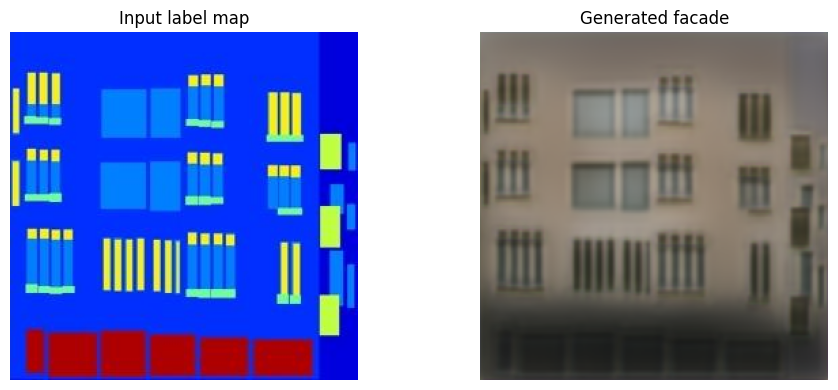

In [4]:
input_img = Image.open(SAMPLE_PATH).convert("RGB")
generated_img = Image.open(OUTPUT_PATH).convert("RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(input_img)
plt.title("Input label map")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_img)
plt.title("Generated facade")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Optional: run inference on a paired Facades image

A paired Facades image contains the real facade on the left and the semantic label map on the right:

```text
[ real facade | label map ]
```

The `--paired` flag tells the script to crop the right half of the image and use it as the input label map.

The following cell is optional. It runs only if `facades/image_001.jpg` exists in the repository.

Running command:
/Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo_env/bin/python /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/inference.py --input /Users/ana/demo_Diego_Gonzales_Ana_Lamas/facades/image_001.jpg --model /Users/ana/demo_Diego_Gonzales_Ana_Lamas/m4_generator_perc_5.pth --output /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/outputs/generated_from_paired.png --paired
Using device: cpu
Generated image saved to: /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/outputs/generated_from_paired.png



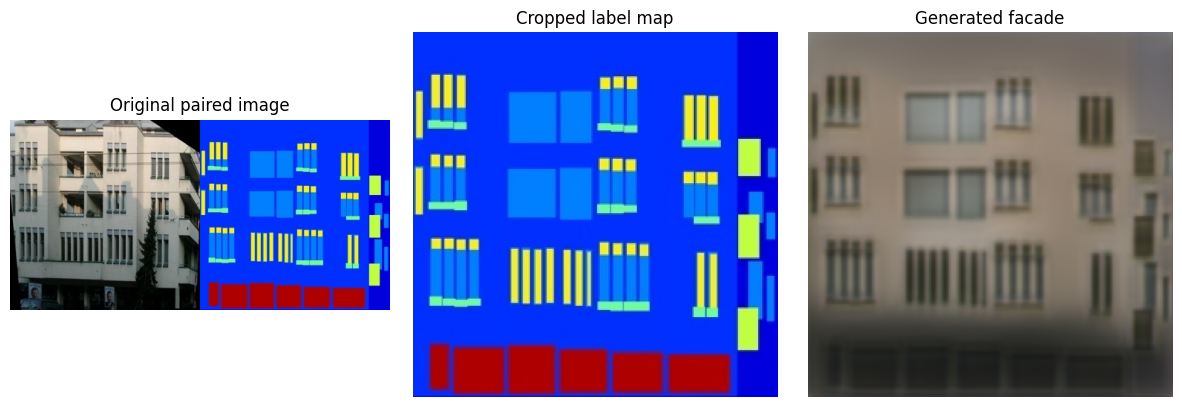

In [5]:
PAIRED_IMAGE_PATH = ROOT / "facades" / "image_001.jpg"
PAIRED_OUTPUT_PATH = DEMO_DIR / "outputs" / "generated_from_paired.png"

if PAIRED_IMAGE_PATH.exists():
    paired_command = [
        sys.executable,
        str(INFERENCE_SCRIPT),
        "--input", str(PAIRED_IMAGE_PATH),
        "--model", str(MODEL_PATH),
        "--output", str(PAIRED_OUTPUT_PATH),
        "--paired",
    ]

    print("Running command:")
    print(" ".join(paired_command))

    result = subprocess.run(
        paired_command,
        cwd=ROOT,
        capture_output=True,
        text=True,
        check=True,
    )

    print(result.stdout)

    paired_input = Image.open(PAIRED_IMAGE_PATH).convert("RGB")
    paired_output = Image.open(PAIRED_OUTPUT_PATH).convert("RGB")

    width, height = paired_input.size
    label_map = paired_input.crop((width // 2, 0, width, height))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(paired_input)
    plt.title("Original paired image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(label_map)
    plt.title("Cropped label map")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(paired_output)
    plt.title("Generated facade")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Optional paired image not found:", PAIRED_IMAGE_PATH)
    print("Skipping paired-image demo.")

## 6. Final check

This cell confirms that the generated output exists.

In [6]:
print("Generated output exists:", OUTPUT_PATH.exists())
print("Generated output path:", OUTPUT_PATH.resolve())

if OUTPUT_PATH.exists():
    output_size_kb = OUTPUT_PATH.stat().st_size / 1024
    print(f"Output size: {output_size_kb:.2f} KB")

Generated output exists: True
Generated output path: /Users/ana/demo_Diego_Gonzales_Ana_Lamas/demo/outputs/generated_sample.png
Output size: 51.59 KB


## Conclusion

This notebook demonstrates how to use the standalone inference script with the selected M4 `.pth` checkpoint.

The actual demo program is `demo/inference.py`. The notebook simply runs that script, displays the generated result and optionally demonstrates the `--paired` input mode for original Facades images.